# 多层感知机（MLP）总结

本notebook整理了《动手学深度学习》第四章的核心概念和代码，涵盖多层感知机的原理、实现和正则化技术。

## 本章结构
1. **多层感知机基础** — 隐藏层、激活函数、通用近似定理
2. **MLP实现** — 从零实现 vs 简洁实现
3. **模型选择** — 欠拟合、过拟合、验证集、交叉验证
4. **正则化技术** — 权重衰减（L2正则化）、暂退法（Dropout）
5. **前向传播与反向传播** — 计算图、链式法则
6. **数值稳定性** — 梯度消失/爆炸、参数初始化
7. **实战：Kaggle房价预测** — 数据预处理、模型训练

## 一、多层感知机基础

### 1.1 为什么需要MLP？

线性模型（如softmax回归）只能表示**线性关系**，但现实世界的数据大多是**非线性**的。

**线性模型的局限**：
- 线性意味着**单调性**：特征增大 → 输出总是增大（或减小）
- 无法捕捉特征之间的**交互作用**
- 例如：体温37°C以上越高越危险，37°C以下越高越安全 → 非单调

### 1.2 MLP的结构

**MLP = 输入层 + 隐藏层（带激活函数） + 输出层**

```
输入 x (d个特征)
  │
  ├──→ 隐藏神经元1 ──┐
  ├──→ 隐藏神经元2 ──┤
  ├──→ 隐藏神经元3 ──┼──→ 输出 (q个类别)
  ├──→ 隐藏神经元4 ──┤
  └──→ 隐藏神经元5 ──┘
```

### 1.3 数学表达

**单隐藏层MLP**：

$$\mathbf{H} = \sigma(\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)})$$

$$\mathbf{O} = \mathbf{H} \mathbf{W}^{(2)} + \mathbf{b}^{(2)}$$

- $\mathbf{X}$：输入矩阵，形状 `(样本数, 特征数)`
- $\mathbf{W}^{(1)}, \mathbf{b}^{(1)}$：隐藏层的权重和偏置
- $\sigma$：**激活函数**（关键！引入非线性） 不可以是线性函数
- $\mathbf{H}$：隐藏层输出（隐藏表示）
- $\mathbf{W}^{(2)}, \mathbf{b}^{(2)}$：输出层的权重和偏置

### 1.4 为什么必须加激活函数？

如果不加激活函数，两层线性变换叠在一起还是线性变换：

$$\mathbf{O} = (\mathbf{X}\mathbf{W}^{(1)} + \mathbf{b}^{(1)})\mathbf{W}^{(2)} + \mathbf{b}^{(2)} = \mathbf{X}\mathbf{W} + \mathbf{b}$$

这跟单层模型完全等价，白加了一层！

### 1.5 通用近似定理

> 只要有一个隐藏层、足够多的神经元、合适的权重，MLP可以拟合**任意连续函数**。

实际中，我们通常用**更深（更多层）而不是更宽（更多神经元）**的网络。

## 二、激活函数详解

激活函数把"线性"变成"非线性"，是MLP的灵魂。

### 2.1 ReLU函数（最常用）

$$\text{ReLU}(x) = \max(x, 0)$$

- 正数保留，负数变0
- 导数：输入>0时为1，输入<0时为0
- **优点**：不会梯度消失，计算快
- **隐藏层首选**

### 2.2 Sigmoid函数

$$\text{sigmoid}(x) = \frac{1}{1 + e^{-x}}$$

- 把任意实数"挤压"到(0, 1)之间
- 最大导数只有0.25 → **梯度消失问题**
- 现在主要用于：二分类输出层、循环神经网络的门控
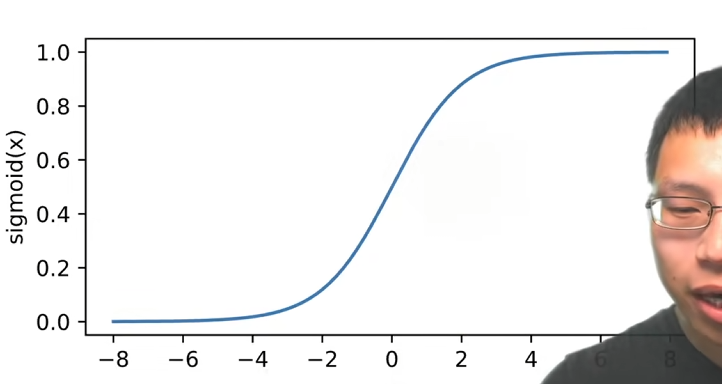

### 2.3 Tanh函数

$$\text{tanh}(x) = \frac{1 - e^{-2x}}{1 + e^{-2x}}$$

- 把任意实数"挤压"到(-1, 1)之间，关于原点对称
- 最大导数为1（比Sigmoid好），但仍有梯度消失问题
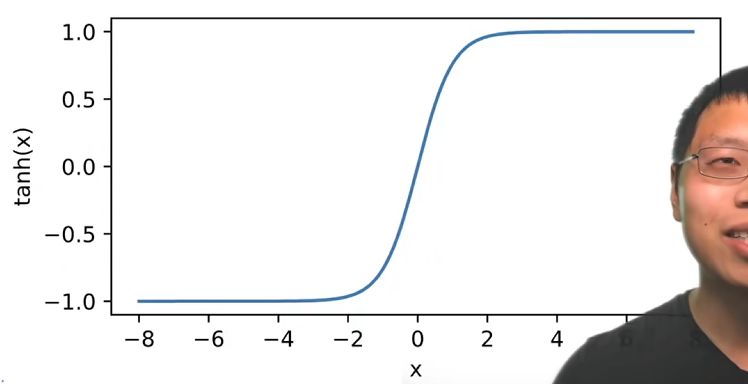

### 2.4 对比表

| 特性 | ReLU | Sigmoid | Tanh |
|------|------|---------|------|
| 输出范围 | [0, +∞) | (0, 1) | (-1, 1) |
| 最大导数 | 1 | 0.25 | 1 |
| 梯度消失 | 不会（正区间） | 严重 | 严重 |
| 使用场景 | 隐藏层首选 | 二分类输出层 | 较少使用 |

### 2.5 激活函数代码演示

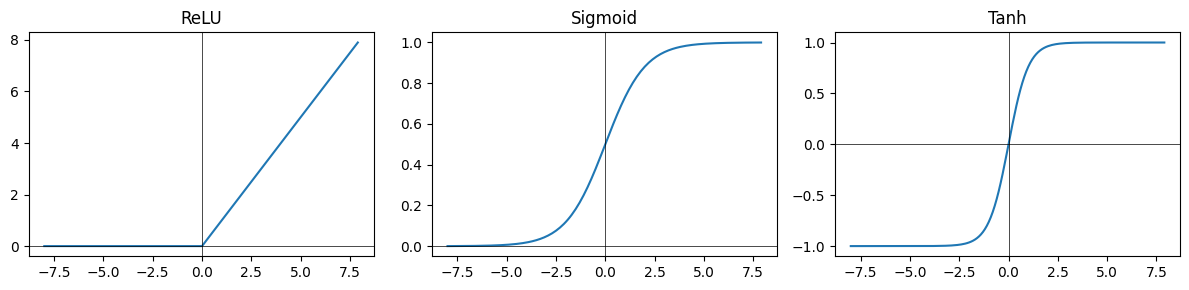

In [1]:
import torch
import matplotlib.pyplot as plt

# 生成输入数据
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)

# 三种激活函数
y_relu = torch.relu(x)
y_sigmoid = torch.sigmoid(x)
y_tanh = torch.tanh(x)

# 绘图
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].plot(x.detach(), y_relu.detach())
axes[0].set_title('ReLU')
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

axes[1].plot(x.detach(), y_sigmoid.detach())
axes[1].set_title('Sigmoid')
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].axvline(x=0, color='k', linewidth=0.5)

axes[2].plot(x.detach(), y_tanh.detach())
axes[2].set_title('Tanh')
axes[2].axhline(y=0, color='k', linewidth=0.5)
axes[2].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

### 2.6 激活函数的导数

C:\Users\lzp\AppData\Local\Temp\ipykernel_60140\4251570182.py:31: UserWarning: Glyph 23548 (\N{CJK UNIFIED IDEOGRAPH-5BFC}) missing from current font.
  plt.tight_layout()
C:\Users\lzp\AppData\Local\Temp\ipykernel_60140\4251570182.py:31: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
d:\allocation\Anaconda3\envs\deeplearning\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23548 (\N{CJK UNIFIED IDEOGRAPH-5BFC}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\allocation\Anaconda3\envs\deeplearning\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


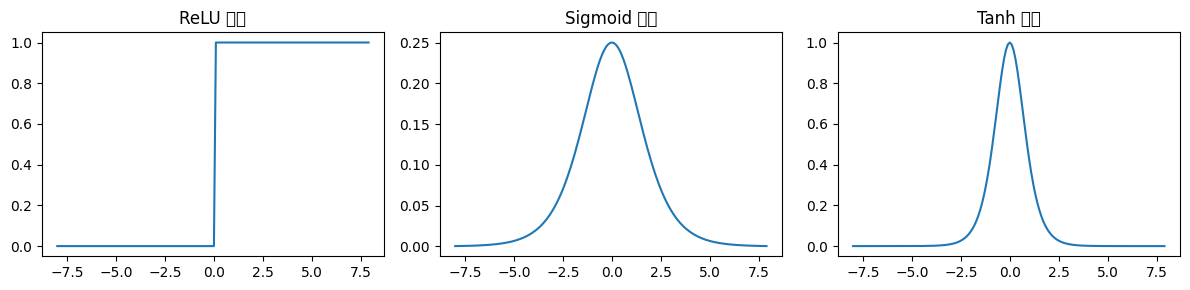

Sigmoid最大导数: 0.2500 (在x=0处)
Tanh最大导数: 1.0000 (在x=0处)


In [2]:
# ReLU的导数
x.grad = None  # 清除之前的梯度
y_relu = torch.relu(x)
y_relu.backward(torch.ones_like(x), retain_graph=True)
grad_relu = x.grad.clone()

# Sigmoid的导数
x.grad = None
y_sigmoid = torch.sigmoid(x)
y_sigmoid.backward(torch.ones_like(x), retain_graph=True)
grad_sigmoid = x.grad.clone()

# Tanh的导数
x.grad = None
y_tanh = torch.tanh(x)
y_tanh.backward(torch.ones_like(x), retain_graph=True)
grad_tanh = x.grad.clone()

# 绘图
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].plot(x.detach(), grad_relu)
axes[0].set_title('ReLU 导数')

axes[1].plot(x.detach(), grad_sigmoid)
axes[1].set_title('Sigmoid 导数')

axes[2].plot(x.detach(), grad_tanh)
axes[2].set_title('Tanh 导数')

plt.tight_layout()
plt.show()

print(f'Sigmoid最大导数: {grad_sigmoid.max():.4f} (在x=0处)')
print(f'Tanh最大导数: {grad_tanh.max():.4f} (在x=0处)')

## 三、MLP从零开始实现

### 3.1 准备数据

In [3]:
import torch
from torch import nn
import sys
sys.path.append('..')
from d2l import torch as d2l

# 加载Fashion-MNIST数据集
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
print('数据加载完成！')
print(f'每次取 {batch_size} 张图片')

数据加载完成！
每次取 256 张图片


### 3.2 初始化模型参数

- 输入：784维（28×28像素）
- 隐藏层：256个神经元
- 输出：10个类别

In [4]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256

# 隐藏层参数: W1(784, 256), b1(256,)
W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))

# 输出层参数: W2(256, 10), b2(10,)
W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]

print(f'W1 shape: {W1.shape}')
print(f'b1 shape: {b1.shape}')
print(f'W2 shape: {W2.shape}')
print(f'b2 shape: {b2.shape}')
print(f'\n总参数数量: {num_inputs*num_hiddens + num_hiddens + num_hiddens*num_outputs + num_outputs}')

W1 shape: torch.Size([784, 256])
b1 shape: torch.Size([256])
W2 shape: torch.Size([256, 10])
b2 shape: torch.Size([10])

总参数数量: 203530


### 3.3 定义激活函数和模型

In [5]:
# ReLU激活函数
def relu(X):
    """ReLU: 负值变0，正值保留"""
    a = torch.zeros_like(X)        # 创建同形状的全0张量
    return torch.max(X, a)         # 逐元素取最大值

# MLP模型
def net(X):
    """前向传播: 输入 → 隐藏层(ReLU) → 输出层"""
    X = X.reshape((-1, num_inputs))  # 展平: (batch, 28, 28) → (batch, 784)
    H = relu(X @ W1 + b1)           # 隐藏层: 线性变换 + ReLU
    return (H @ W2 + b2)            # 输出层: 线性变换（不加激活）

# 数据流向演示
X_demo = torch.randn(2, 1, 28, 28)  # 2张图片
X_flat = X_demo.reshape((-1, num_inputs))
print(f'输入shape: {X_demo.shape}')
print(f'展平后: {X_flat.shape}')
print(f'隐藏层输出: {relu(X_flat @ W1 + b1).shape}')
print(f'最终输出: {(relu(X_flat @ W1 + b1) @ W2 + b2).shape}')

输入shape: torch.Size([2, 1, 28, 28])
展平后: torch.Size([2, 784])
隐藏层输出: torch.Size([2, 256])
最终输出: torch.Size([2, 10])


### 3.4 定义损失函数和训练

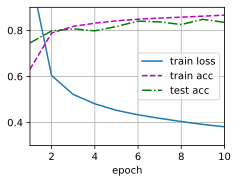

In [6]:
# 交叉熵损失函数
loss = nn.CrossEntropyLoss(reduction='none')

# 训练参数
num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)

# 训练模型
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

## 四、MLP简洁实现（使用框架）

使用PyTorch的`nn.Sequential`可以更简洁地定义模型。

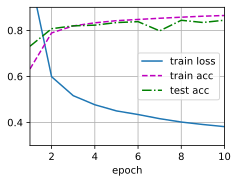

In [7]:
# 使用 nn.Sequential 搭建顺序网络：层按顺序依次执行
net_concise = nn.Sequential(
    # 展平层：把每张 28×28 的图像拉成一维向量
    # 输入形状：(batch_size, 28, 28)  -> 输出形状：(batch_size, 784)
    nn.Flatten(),          
    
    # 全连接层（线性层）：输入784个神经元，输出256个神经元
    # 完成 784维特征 → 256维隐藏特征的映射
    nn.Linear(784, 256),   
    
    # ReLU 激活函数：引入非线性，让网络能拟合复杂规律
    nn.ReLU(),             
    
    # 输出层全连接：256维隐藏特征 → 10维输出
    # Fashion-MNIST 共10个类别，输出对应每一类的预测得分
    nn.Linear(256, 10)     
)

# ===================== 2. 自定义权重初始化函数 =====================
def init_weights(m):
    # 判断当前层是否是 全连接层(Linear)
    if type(m) == nn.Linear:
        # 对全连接层的权重做**正态分布初始化**
        # 均值默认0，标准差 std=0.01
        nn.init.normal_(m.weight, std=0.01)

# 遍历网络所有层，执行上面的权重初始化函数
net_concise.apply(init_weights)

# ===================== 3. 超参数设置 =====================
# batch_size：每批训练样本数；lr：学习率；num_epochs：训练轮数
batch_size, lr, num_epochs = 256, 0.1, 10

# 损失函数：交叉熵损失（分类任务标准损失）
# reduction='none'：不自动求均值/求和，保留每个样本的损失值
loss = nn.CrossEntropyLoss(reduction='none')

# 优化器：SGD 随机梯度下降，更新网络参数，学习率 lr=0.1
trainer = torch.optim.SGD(net_concise.parameters(), lr=lr)

# ===================== 4. 加载数据集 =====================
# 加载 Fashion-MNIST 训练集、测试集迭代器，批次大小为 batch_size
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

# ===================== 5. 启动训练 =====================
# d2l 封装好的第3章训练函数：
# 依次执行：前向传播 → 计算损失 → 反向传播 → 参数更新
# 同时打印/绘制 训练损失、训练精度、测试精度
d2l.train_ch3(net_concise, train_iter, test_iter, loss, num_epochs, trainer)

## 五、模型选择、欠拟合和过拟合

### 5.1 核心概念

| 概念 | 含义 | 症状 |
|------|------|------|
| **欠拟合** | 模型太简单，没学到规律 | 训练误差高，验证误差也高 |
| **过拟合** | 模型太复杂，把噪声也学了 | 训练误差低，验证误差高 |
| **刚好** | 模型复杂度适中 | 两者都较低且接近 |

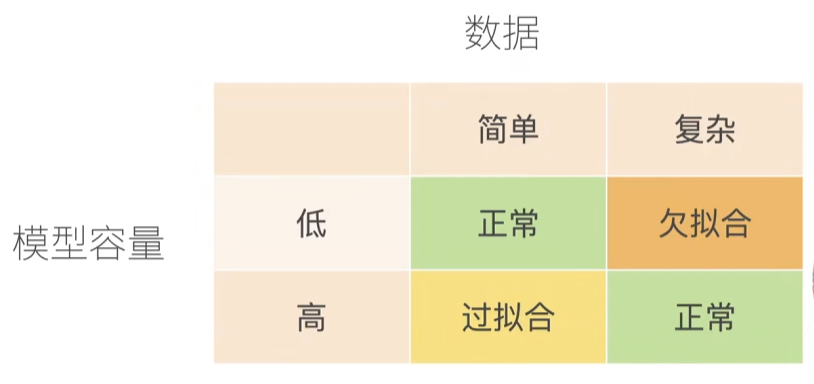
- **模型容量**：拟合各种函数的能力。低容量的模型难以拟合训练数据，高容量可以记住所有的训练数据。
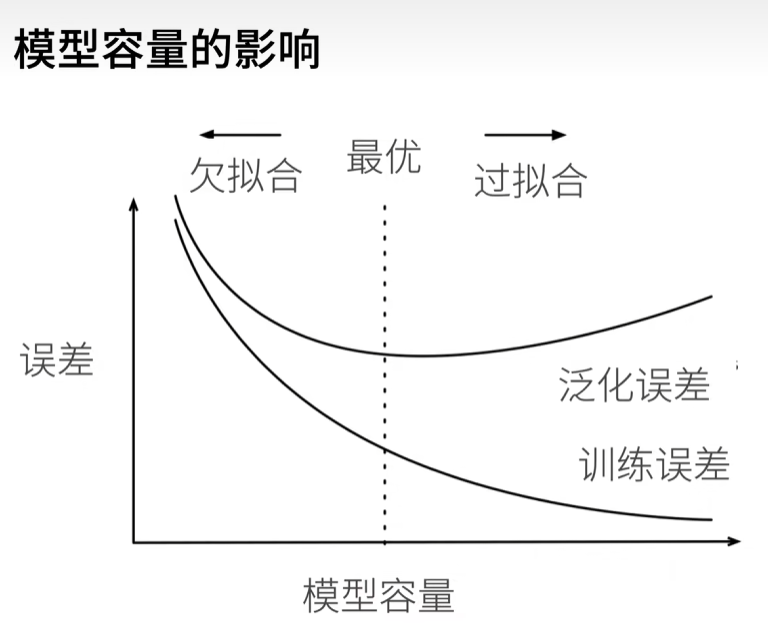

### 5.2 关键概念

- **训练误差**：模型在训练数据上的误差
- **泛化误差**：模型在新数据上的期望误差（无法精确计算，重要关注的）
- **验证集**：用于模型选择，不能用于最终评估
- **测试集**：只可使用一次。
- **K折交叉验证**：数据少时的模型选择方法

### 5.3 影响过拟合的因素

1. **模型复杂度**：参数越多 → 越容易过拟合
2. **数据量**：数据越少 → 越容易过拟合
3. **训练时间**：训练越久 → 越容易过拟合

### 5.4 多项式回归实验（直观感受欠拟合和过拟合）

真实数据：三阶多项式 $y = 5 + 1.2x - 3.4\frac{x^2}{2!} + 5.6\frac{x^3}{3!} + \epsilon$

In [8]:
import math
import numpy as np

# 生成数据集
max_degree = 20  # 最大阶数
n_train, n_test = 100, 100
true_w = np.zeros(max_degree)
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])  # 真实系数

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # 除以i!
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

# 转为tensor
true_w, features, poly_features, labels = [
    torch.tensor(x, dtype=torch.float32) 
    for x in [true_w, features, poly_features, labels]
]

print(f'特征shape: {features.shape}')
print(f'多项式特征shape: {poly_features.shape}')
print(f'标签shape: {labels.shape}')

特征shape: torch.Size([200, 1])
多项式特征shape: torch.Size([200, 20])
标签shape: torch.Size([200])


In [9]:
def evaluate_loss(net, data_iter, loss):
    """评估模型损失"""
    metric = d2l.Accumulator(2)
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

def train_poly(train_features, test_features, train_labels, test_labels,
               num_epochs=400):
    """训练多项式回归"""
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)), batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    
    train_losses, test_losses = [], []
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            train_losses.append(evaluate_loss(net, train_iter, loss))
            test_losses.append(evaluate_loss(net, test_iter, loss))
    
    print(f'训练损失: {train_losses[-1]:.6f}')
    print(f'测试损失: {test_losses[-1]:.6f}')
    return train_losses, test_losses

In [10]:
# 情况1: 三阶多项式（刚好匹配真实数据）
print('=== 三阶多项式（正常） ===')
train_poly(poly_features[:n_train, :4], poly_features[n_train:, :4],
           labels[:n_train], labels[n_train:])

=== 三阶多项式（正常） ===
训练损失: 0.011784
测试损失: 0.012281


([15.642710800170898,
  1.6985899269580842,
  0.6467704319953919,
  0.3593065845966339,
  0.2232656842470169,
  0.14325716853141784,
  0.09384014338254928,
  0.06303472846746444,
  0.04377966955304146,
  0.031735459119081495,
  0.024215884134173395,
  0.01951204374432564,
  0.016570620834827424,
  0.014732693508267402,
  0.013584375753998757,
  0.012866667807102203,
  0.012418065294623375,
  0.012137324437499047,
  0.011961742341518401,
  0.011852275133132934,
  0.011783519834280014],
 [29.351167602539064,
  4.566272125244141,
  1.9145434761047364,
  1.0519328653812408,
  0.6273561254143715,
  0.3801150315999985,
  0.2300245323777199,
  0.13848762720823288,
  0.08443752154707909,
  0.051728158369660375,
  0.0328092485666275,
  0.02193342685699463,
  0.016027928479015827,
  0.012894090563058853,
  0.011463023275136947,
  0.010966687351465226,
  0.01095811989158392,
  0.011196709983050824,
  0.011559211537241936,
  0.01190557774156332,
  0.012281287126243115])

In [11]:
# 情况2: 线性模型（欠拟合）
print('=== 线性模型（欠拟合） ===')
train_poly(poly_features[:n_train, :2], poly_features[n_train:, :2],
           labels[:n_train], labels[n_train:])

=== 线性模型（欠拟合） ===
训练损失: 5.299590
测试损失: 15.097255


([22.090233612060548,
  5.306969356536865,
  5.29962272644043,
  5.299675579071045,
  5.299604511260986,
  5.299712247848511,
  5.299607944488526,
  5.299635105133056,
  5.299606561660767,
  5.299597053527832,
  5.299606018066406,
  5.299684009552002,
  5.299644470214844,
  5.299604969024658,
  5.2995928859710695,
  5.299589881896972,
  5.299622535705566,
  5.29967842578888,
  5.299615783691406,
  5.300121765136719,
  5.299589576721192],
 [39.01910552978516,
  15.20455244064331,
  15.103904333114624,
  15.066576862335205,
  15.08200608253479,
  15.136205701828002,
  15.083555421829224,
  15.074856557846068,
  15.087129049301147,
  15.099873094558715,
  15.083975419998168,
  15.066274185180664,
  15.124432640075684,
  15.113582372665405,
  15.1099937915802,
  15.108437776565552,
  15.11915927886963,
  15.066701192855835,
  15.11116512298584,
  15.022613172531129,
  15.097254657745362])

In [12]:
# 情况3: 高阶多项式（过拟合）
print('=== 高阶多项式（过拟合） ===')
train_poly(poly_features[:n_train, :], poly_features[n_train:, :],
           labels[:n_train], labels[n_train:], num_epochs=1500)

=== 高阶多项式（过拟合） ===
训练损失: 0.012811
测试损失: 0.041241


([19.847601776123046,
  1.8414981746673584,
  0.7166145300865173,
  0.4019991397857666,
  0.24595308542251587,
  0.15493618786334992,
  0.1003212085366249,
  0.06737233251333237,
  0.04742576733231545,
  0.0353416608273983,
  0.027988010346889497,
  0.023484200090169906,
  0.02071081280708313,
  0.01897702433168888,
  0.017871262580156325,
  0.01714950330555439,
  0.016659865565598012,
  0.016312533468008043,
  0.01605277953669429,
  0.01584746927022934,
  0.015678202882409096,
  0.015529969930648804,
  0.0153983573615551,
  0.015277394577860832,
  0.015164809674024582,
  0.01505839116871357,
  0.0149575424939394,
  0.014861587807536126,
  0.014769305028021335,
  0.014681871831417084,
  0.01459627330303192,
  0.014515280947089195,
  0.014436563774943352,
  0.014361312836408615,
  0.014289260953664779,
  0.014219572991132736,
  0.014152577370405197,
  0.014088124334812165,
  0.014026389569044112,
  0.013966518118977547,
  0.01390917994081974,
  0.013854171708226204,
  0.0138009508699178

## 六、权重衰减 weight decay（L2正则化）

### 6.1 核心思想

在损失函数中加一个惩罚项，让权重不要太大：

$$L(\mathbf{w}, b) + \frac{\lambda}{2} \|\mathbf{w}\|^2$$

- $\lambda$：正则化强度（超参数），越大惩罚越重
- $\|\mathbf{w}\|^2$：权重的L2范数的平方

**通俗理解**："我不光要预测得准，还要求权重尽量小。"

 权重衰减的作用

- 约束权重大小：不断把权重往 0 拉近，避免权重变得过大，降低模型对噪声的敏感度。
- 抑制过拟合：让模型不去 “死记” 训练集的零散噪音，专注学习数据里真正的通用规律。
- 间接让模型变得更简单，简单模型更不容易过拟合。

### 6.2 为什么叫"权重衰减"？

梯度下降更新时，权重先乘以 $(1 - \eta\lambda) < 1$，相当于每次"衰减"一点。

### 6.3 L1 vs L2 正则化

| 特性 | L2（权重衰减） | L1（套索回归） |
|------|---------------|---------------|
| 惩罚项 | $\|\mathbf{w}\|^2 = \sum w_i^2$ | $\|\mathbf{w}\|_1 = \sum |w_i|$ |
| 效果 | 权重均匀变小 | 部分权重变0（特征选择） |
| 别名 | 岭回归（Ridge） | 套索回归（Lasso） |

### 6.4 权重衰减代码实现

In [19]:
# 生成高维数据（200维特征，只有20个样本 → 容易过拟合）
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05

train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

print(f'训练样本: {n_train}, 测试样本: {n_test}, 特征数: {num_inputs}')

训练样本: 20, 测试样本: 100, 特征数: 200


In [18]:
# 初始化模型权重w、偏置b
def init_params():
    """初始化参数"""
    # 生成正态分布随机权重，开启梯度追踪，用于后续更新
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    # 偏置初始化为0，开启梯度追踪
    b = torch.zeros(1, requires_grad=True)
    # 返回权重、偏置列表
    return [w, b]

# 定义L2惩罚项（权重衰减的数学实现）
def l2_penalty(w):
    """L2范数惩罚项"""
    # 计算权重所有元素平方和，再除以2，对应L2正则公式
    return torch.sum(w.pow(2)) / 2

# 带权重衰减的完整训练函数，lambd是惩罚系数λ
def train_weight_decay(lambd):
    """带权重衰减的训练"""
    # 调用函数，拿到初始化好的w和b
    w, b = init_params()
    # 匿名函数：封装线性回归模型，输入X，输出预测值
    net = lambda X: d2l.linreg(X, w, b)
    # 加载之前定义的均方损失函数
    loss = d2l.squared_loss
    # 设置训练总轮数、学习率
    num_epochs, lr = 100, 0.003
    
    # 新建列表，保存每轮的训练集损失、测试集损失
    train_losses, test_losses = [], []
    # 开始循环训练，一共100轮
    for epoch in range(num_epochs):
        # 遍历训练集每一个小批量数据
        for X, y in train_iter:
            # 核心：原始损失 + λ*L2惩罚项 = 总损失（实现权重衰减）
            l = loss(net(X), y) + lambd * l2_penalty(w)
            # 总损失反向传播，计算w、b的梯度
            l.sum().backward()
            # 小批量随机梯度下降，更新w和b
            d2l.sgd([w, b], lr, batch_size)
        # 每训练20轮，记录一次训练集、测试集损失
        if (epoch + 1) % 20 == 0:
            # 计算并保存当前训练集整体损失
            train_losses.append(d2l.evaluate_loss(net, train_iter, loss))
            # 计算并保存当前测试集整体损失
            test_losses.append(d2l.evaluate_loss(net, test_iter, loss))
    
    # 输出最终权重w的L2范数（直观查看权重大小）
    print(f'w的L2范数: {torch.norm(w).item():.4f}')
    # 返回全程记录的损失数据，用于绘图/分析
    return train_losses, test_losses

In [16]:
# 不使用权重衰减 (lambda=0) → 过拟合
print('=== 不使用权重衰减 (λ=0) ===')
train_losses_no_decay, test_losses_no_decay = train_weight_decay(lambd=0)

=== 不使用权重衰减 (λ=0) ===
w的L2范数: 13.1852


In [17]:
# 使用权重衰减 (lambda=3) → 正则化效果
print('=== 使用权重衰减 (λ=3) ===')
train_losses_decay, test_losses_decay = train_weight_decay(lambd=3)

=== 使用权重衰减 (λ=3) ===
w的L2范数: 0.3372


### 6.5 简洁实现（使用PyTorch内置weight_decay）

In [ ]:
def train_concise(wd):
    """简洁实现权重衰减"""
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    
    # 关键：weight_decay参数
    trainer = torch.optim.SGD([
        {'params': net[0].weight, 
         'weight_decay': wd},  # 权重使用权重衰减
        {'params': net[0].bias}],                        # 偏置不使用权重衰减
        lr=lr)
    
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
    
    print(f'w的L2范数: {net[0].weight.norm().item():.4f}')

print('=== 简洁实现: 不使用权重衰减 ===')
train_concise(0)
print('\n=== 简洁实现: 使用权重衰减 ===')
train_concise(3)

=== 简洁实现: 不使用权重衰减 ===
w的L2范数: 12.9925

=== 简洁实现: 使用权重衰减 ===
w的L2范数: 0.3683


## 七、暂退法（Dropout）

### 7.1 核心思想

在训练时，随机"丢弃"一些神经元（把输出设为0）。

**类比**：团队中每个人可能随时"请假"，所以每个人都要能独立工作，不能过度依赖别人。

### 7.2 工作原理

对隐藏层输出 $h$，以概率 $p$ 进行：

$$h' = \begin{cases} 0 & \text{概率为 } p \\ \frac{h}{1-p} & \text{其他情况} \end{cases}$$

除以 $(1-p)$ 是为了保持期望值不变：$E[h'] = h$

### 7.3 关键点

- **训练时**：使用Dropout，随机丢弃神经元
- **测试时**：不使用Dropout，使用完整模型
- 常见技巧：靠近输入层用较小的丢弃率，靠近输出层用较大的丢弃率

### 7.4 Dropout从零实现

In [ ]:
def dropout_layer(X, dropout):
    """Dropout层实现"""
    assert 0 <= dropout <= 1
    if dropout == 1:           # 丢弃率100%：全部丢弃
        return torch.zeros_like(X)
    if dropout == 0:           # 丢弃率0%：全部保留
        return X
    mask = (torch.rand(X.shape) > dropout).float()  # 生成0/1掩码
    return mask * X / (1.0 - dropout)               # 丢弃 + 缩放

# 测试Dropout
X = torch.arange(16, dtype=torch.float32).reshape((2, 8))
print('原始输入:')
print(X)
print('\ndropout=0（全部保留）:')
print(dropout_layer(X, 0.))
print('\ndropout=0.5（随机丢弃50%）:')
print(dropout_layer(X, 0.5))
print('\ndropout=1（全部丢弃）:')
print(dropout_layer(X, 1.))

In [ ]:
# 定义带Dropout的模型
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training=True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        if self.training:              # 只在训练时使用dropout
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training:
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out

# 训练
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256
net_dropout = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net_dropout.parameters(), lr=lr)
d2l.train_ch3(net_dropout, train_iter, test_iter, loss, num_epochs, trainer)

### 7.5 简洁实现（使用nn.Dropout）

In [ ]:
net_dropout_concise = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Dropout(dropout1),      # 第一层后加Dropout
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Dropout(dropout2),      # 第二层后加Dropout
    nn.Linear(256, 10)
)

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net_dropout_concise.apply(init_weights)

# 训练
trainer = torch.optim.SGD(net_dropout_concise.parameters(), lr=lr)
d2l.train_ch3(net_dropout_concise, train_iter, test_iter, loss, num_epochs, trainer)

## 八、前向传播与反向传播

### 8.1 前向传播（Forward Propagation）

从输入层到输出层，依次计算每一层的输出：

```
输入 x
  → z = W¹x           （线性变换）
  → h = φ(z)          （激活函数）
  → o = W²h           （输出层）
  → L = l(o, y)       （计算损失）
  → J = L + s          （目标函数 = 损失 + 正则项）
```

### 8.2 反向传播（Backward Propagation）

从输出层到输入层，利用**链式法则**计算每个参数的梯度：

$$\frac{\partial Z}{\partial X} = \frac{\partial Z}{\partial Y} \cdot \frac{\partial Y}{\partial X}$$

```
目标函数 J
  → ∂J/∂o        （输出对损失的梯度）
  → ∂J/∂W²       （输出层权重的梯度）
  → ∂J/∂h        （隐藏层输出的梯度）
  → ∂J/∂z        （激活函数前的梯度）
  → ∂J/∂W¹       （隐藏层权重的梯度）
```

### 8.3 训练中的依赖关系

- **前向传播**：需要当前参数值 → 计算中间变量和损失
- **反向传播**：需要中间变量 → 计算梯度
- **参数更新**：需要梯度 → 更新参数

**为什么训练比预测需要更多内存？**
训练时需要保存所有中间变量（用于反向传播），大小与网络层数和batch size成正比。

## 九、数值稳定性和模型初始化

### 9.1 梯度消失和梯度爆炸

| 问题 | 现象 | 后果 |
|------|------|------|
| **梯度消失** | 梯度越来越接近0 | 靠近输入层的参数几乎不更新 |
| **梯度爆炸** | 梯度越来越大 | 参数更新太猛，模型发散 |

**Sigmoid导致梯度消失**：最大导数只有0.25，经过n层后梯度变成$(0.25)^n$

### 9.2 打破对称性

如果所有权重初始化为相同的值，每个神经元学到的东西完全一样。

**解决方法：随机初始化！**

### 9.3 Xavier初始化

让每一层的输出方差保持稳定：

$$\sigma = \sqrt{\frac{2}{n_{\text{in}} + n_{\text{out}}}}$$

### 9.4 梯度消失演示

In [ ]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.backward(torch.ones_like(x))

plt.figure(figsize=(8, 4))
plt.plot(x.detach(), y.detach(), label='sigmoid')
plt.plot(x.detach(), x.grad, label='gradient')
plt.legend()
plt.title('Sigmoid函数及其梯度')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()

print(f'Sigmoid最大梯度: {x.grad.max():.4f}')
print('注意：输入远离0时，梯度接近0 → 梯度消失！')

### 9.5 梯度爆炸演示

In [ ]:
M = torch.normal(0, 1, size=(4, 4))
print('一个矩阵:')
print(M)

for i in range(100):
    M = torch.mm(M, torch.normal(0, 1, size=(4, 4)))

print('\n乘以100个矩阵后:')
print(M)
print('\n注意：数值已经爆炸到 10^26 量级！')

## 十、环境和分布偏移

### 10.1 什么是分布偏移？

训练数据和测试数据来自不同的分布，导致模型在实际应用中表现差。

### 10.2 三种分布偏移类型

| 类型 | 变化的是什么 | 例子 |
|------|-------------|------|
| **协变量偏移** | 输入分布P(x)变了，P(y\|x)没变 | 训练用真实照片，测试用卡通 |
| **标签偏移** | 标签分布P(y)变了，P(x\|y)没变 | 疾病流行率变了，症状没变 |
| **概念偏移** | P(y\|x)本身变了 | "软饮"在不同地区叫法不同 |

### 10.3 现实案例

1. **医学诊断**：用大学生血样训练 → 用到老年人身上（完全不适用）
2. **自动驾驶**：用游戏渲染数据训练 → 真实道路不行
3. **广告模型**：2009年训练的模型不知道iPad是什么
4. **垃圾邮件**：垃圾邮件发送者不断进化

### 10.4 解决思路

- **协变量偏移**：给训练样本加权
- **标签偏移**：通过混淆矩阵估计目标分布
- **概念偏移**：用新数据持续更新模型

## 十一、实战：Kaggle房价预测

### 11.1 数据预处理

In [ ]:
import pandas as pd

# 读取数据
train_data = pd.read_csv(d2l.download('kaggle_house_train'))
test_data = pd.read_csv(d2l.download('kaggle_house_test'))

print(f'训练集: {train_data.shape}')
print(f'测试集: {test_data.shape}')
print(f'\n前4个样本的几个特征:')
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])

In [ ]:
# 合并特征（去掉ID和标签）
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))

# 数值特征标准化: (x - 均值) / 标准差
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))
all_features[numeric_features] = all_features[numeric_features].fillna(0)

# 类别特征独热编码
all_features = pd.get_dummies(all_features, dummy_na=True)
print(f'独热编码后特征数: {all_features.shape[1]}')

# 转为tensor
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(
    train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

print(f'\n训练特征shape: {train_features.shape}')
print(f'训练标签shape: {train_labels.shape}')

### 11.2 定义模型和评估指标

In [ ]:
loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    """简单线性模型作为基线"""
    return nn.Sequential(nn.Linear(in_features, 1))

def log_rmse(net, features, labels):
    """对数RMSE：衡量相对误差"""
    clipped_preds = torch.clamp(net(features), 1, float('inf'))  # 预测值限制>=1
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

print('为什么用对数RMSE？')
print('房价是"相对"的：偏差10万对12.5万的房子是大误差，对400万的房子是小误差')
print('取对数后，变成相对误差的度量')

### 11.3 K折交叉验证

In [ ]:
def get_k_fold_data(k, i, X, y):
    """获取第i折的数据"""
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

def train_k_fold(net, train_features, train_labels, test_features, test_labels,
                 num_epochs, learning_rate, weight_decay, batch_size):
    """训练函数"""
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr=learning_rate,
                                 weight_decay=weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,
           batch_size):
    """K折交叉验证"""
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train_k_fold(net, *data, num_epochs, learning_rate,
                                          weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        print(f'折{i+1}，训练log rmse: {float(train_ls[-1]):f}, '
              f'验证log rmse: {float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

In [ ]:
# 训练
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'\n{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

## 十二、本章核心知识总结

### MLP vs 线性模型

| 对比项 | 线性模型 | MLP |
|--------|----------|-----|
| 结构 | 输入 → 输出 | 输入 → 隐藏层(激活) → 输出 |
| 表达能力 | 只能表示线性关系 | 可以表示任意函数 |
| 激活函数 | 无 | 必须有（否则退化为线性） |

### 正则化技术对比

| 技术 | 原理 | 使用场景 |
|------|------|----------|
| **权重衰减** | 在损失函数中加L2惩罚项 | 权重太大时 |
| **Dropout** | 训练时随机丢弃神经元 | 过拟合时 |

### 关键术语速查表

| 术语 | 英文 | 核心含义 |
|------|------|----------|
| 多层感知机 | multilayer perceptron | 有隐藏层的神经网络 |
| 隐藏层 | hidden layer | 输入和输出之间的层 |
| 激活函数 | activation function | 引入非线性（ReLU, Sigmoid, Tanh） |
| ReLU | rectified linear unit | max(x,0)，隐藏层首选 |
| 欠拟合 | underfitting | 模型太简单，训练测试都差 |
| 过拟合 | overfitting | 模型太复杂，训练好测试差 |
| 验证集 | validation set | 用于模型选择的数据 |
| 权重衰减 | weight decay | L2正则化 |
| 暂退法 | dropout | 随机丢弃神经元 |
| 前向传播 | forward propagation | 从输入到输出计算 |
| 反向传播 | backward propagation | 从输出到输入计算梯度 |
| 梯度消失 | gradient vanishing | 梯度越来越小 |
| 梯度爆炸 | gradient exploding | 梯度越来越大 |
| Xavier初始化 | Xavier initialization | 保持方差稳定的初始化 |
| 分布偏移 | distribution shift | 训练测试分布不同 |
| K折交叉验证 | K-fold cross validation | 数据少时的模型选择 |